#### Análise Exploratória e Dashboard em Python - Câncer de Mama
###### *4º semestre - Ciência de Dados*

**Professor**: Rômulo Francisco de Souza

**Aluna**: Maria Eduarda da Cruz de Camargo


#### 01. Introdução
######

1.1. Importando Bibliotecas

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("dataset_cancer_mama_02.xlsx")
df["Tipo de Diagnóstico"] = df["diagnóstico"].map({0: "Maligno", 1: "Benigno"})

df.head()

,raio médio,textura média,perímetro médio,área média,suavidade média,compacidade média,concavidade média,pontos côncavos médios,simetria média,dimensão fractal média,...,pior perímetro,pior área,pior suavidade,pior compacidade,pior concavidade,piores pontos côncavos,pior simetria,pior dimensão fractal,diagnóstico,Tipo de Diagnóstico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Maligno
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Maligno
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Maligno
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Maligno
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Maligno


1.2. Visão Geral do Dataset

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   raio médio                569 non-null    float64
 1   textura média             569 non-null    float64
 2   perímetro médio           569 non-null    float64
 3   área média                569 non-null    float64
 4   suavidade média           569 non-null    float64
 5   compacidade média         569 non-null    float64
 6   concavidade média         569 non-null    float64
 7   pontos côncavos médios    569 non-null    float64
 8   simetria média            569 non-null    float64
 9   dimensão fractal média    569 non-null    float64
 10  erro do raio              569 non-null    float64
 11  erro da textura           569 non-null    float64
 12  erro do perímetro         569 non-null    float64
 13  erro da área              569 non-null    float64
 14  erro da su

In [32]:
df.describe()

,raio médio,textura média,perímetro médio,área média,suavidade média,compacidade média,concavidade média,pontos côncavos médios,simetria média,dimensão fractal média,...,pior textura,pior perímetro,pior área,pior suavidade,pior compacidade,pior concavidade,piores pontos côncavos,pior simetria,pior dimensão fractal,diagnóstico
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,706.771388,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,2.111808,4.410401,0.114606,0.290076,0.083946,0.627417
std,2430.243368,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,44.343334,69.928599,0.065732,0.061867,0.018061,0.483918
min,7.760000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,12.210000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.850000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,17.680000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,9904.000000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1058.000000,1252.000000,0.291000,0.663800,0.207500,1.000000


In [33]:

#Estética dos Gráficos

titulo_grafico = "Distribuição dos Diagnósticos"
texto_eixo_x = "Tipo de Diagnóstico"
texto_eixo_y = "Quantidade de Casos"

cor_unica = "#d98ca3"

paleta_diagnostico = {
    "Benigno": "#7fbf7b",
    "Maligno": "#c06c84"
}

tamanho_figura = (8, 5)
rotacao_x = 0

#### 2. Visualização dos Dados


2.1 Distribuição dos Diagnósticos

In [6]:
def grafico_contagem(df, coluna, titulo, xlabel, ylabel, palette=None, color=None, figsize=(8,5), rotacao_x=0):
    plt.figure(figsize=figsize)
    
    sns.countplot(
        data=df,
        x=coluna,
        palette=palette,
        color=color
    )
    
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotacao_x)
    plt.tight_layout()
    plt.show()

C:\Users\Fenec\AppData\Local\Temp\ipykernel_20100\798101542.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


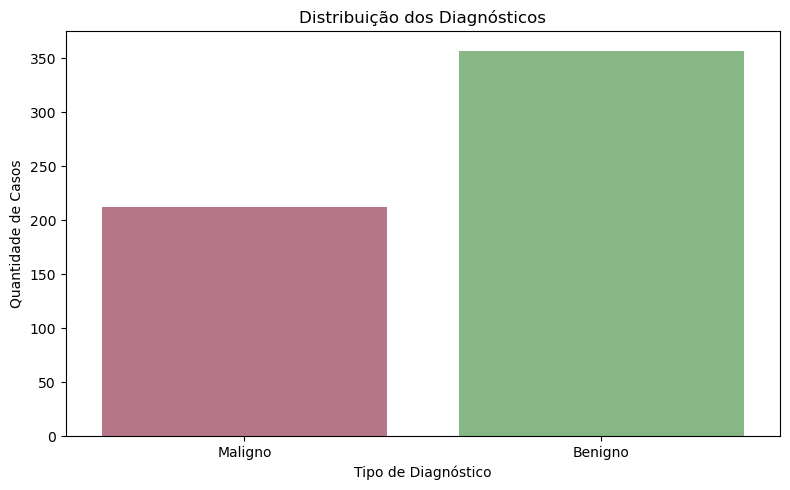

In [7]:
grafico_contagem(
    df=df,
    coluna= "Tipo de Diagnóstico",
    titulo=titulo_grafico,
    xlabel=texto_eixo_x,
    ylabel=texto_eixo_y,
    palette=paleta_diagnostico,
    figsize=tamanho_figura,
    rotacao_x=rotacao_x
)

2.2 Textura Média por Diagnóstico

In [8]:
def grafico_media(df, x, y, titulo, eixo_x, eixo_y, paleta):
    plt.figure(figsize=(8, 5))
    
    sns.barplot(
        data=df,
        x=x,
        y=y,
        hue=x,
        palette=paleta,
        legend=False
    )
    
    plt.title(titulo)
    plt.xlabel(eixo_x)
    plt.ylabel(eixo_y)
    plt.tight_layout()
    plt.show()

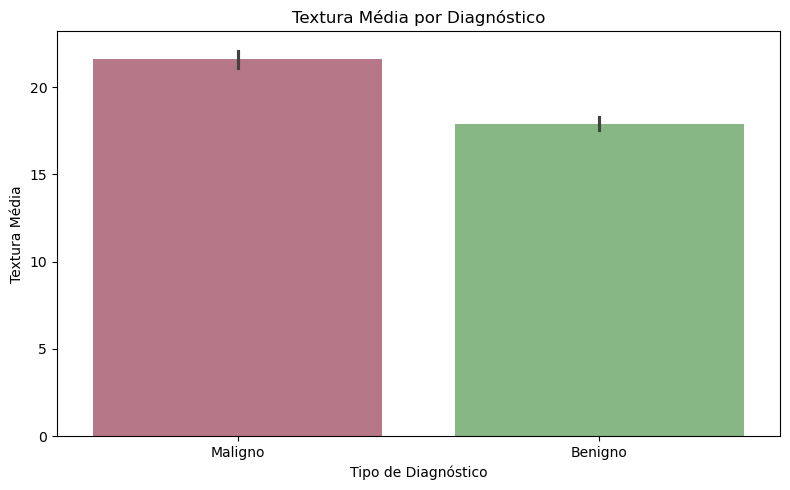

In [9]:
grafico_media(
    df=df,
    x="Tipo de Diagnóstico",
    y="textura média",
    titulo="Textura Média por Diagnóstico",
    eixo_x="Tipo de Diagnóstico",
    eixo_y="Textura Média",
    paleta=paleta_diagnostico
)

2.3 Distribuição da Área Média por Diagnóstico

In [17]:
def grafico_histograma_hue(df, coluna, hue, titulo, eixo_x, eixo_y, paleta):
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=df,
        x=coluna,
        hue=hue,
        kde=True,
        palette=paleta
    )
    
    plt.title(titulo)
    plt.xlabel(eixo_x)
    plt.ylabel(eixo_y)
    plt.tight_layout()
    plt.show()

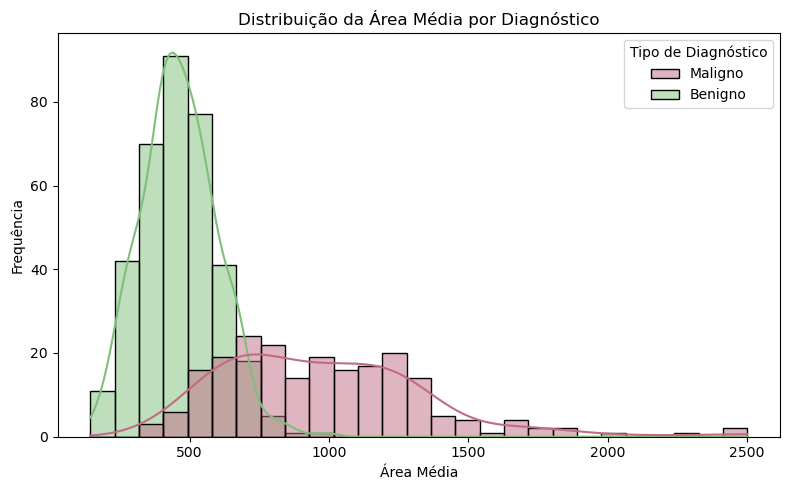

In [18]:
grafico_histograma_hue(
    df=df,
    coluna="área média",
    hue="Tipo de Diagnóstico",
    titulo="Distribuição da Área Média por Diagnóstico",
    eixo_x="Área Média",
    eixo_y="Frequência",
    paleta=paleta_diagnostico
)

2.4 Simetria x Concavidade por Diagnóstico

In [20]:
def grafico_dispersao(df, x, y, hue, titulo, eixo_x, eixo_y, paleta):
    plt.figure(figsize=(8, 5))
    
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue=hue,
        palette=paleta
    )
    
    plt.title(titulo)
    plt.xlabel(eixo_x)
    plt.ylabel(eixo_y)
    plt.tight_layout()
    plt.show()

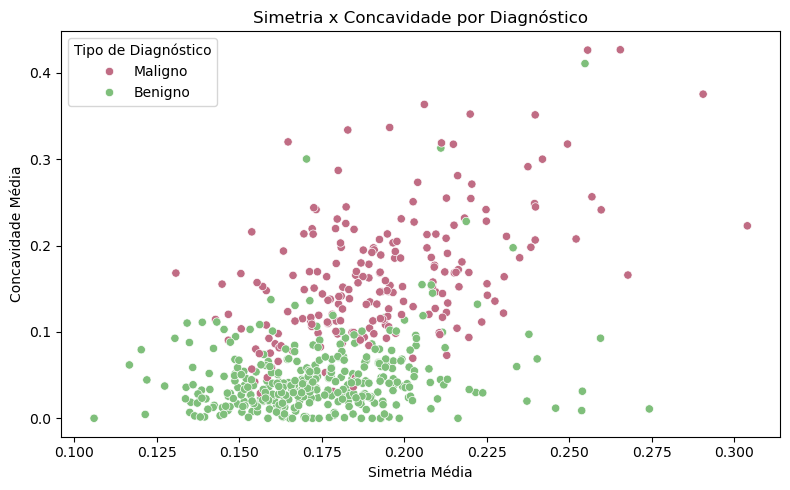

In [21]:
grafico_dispersao(
    df=df,
    x="simetria média",
    y="concavidade média",
    hue="Tipo de Diagnóstico",
    titulo="Simetria x Concavidade por Diagnóstico",
    eixo_x="Simetria Média",
    eixo_y="Concavidade Média",
    paleta=paleta_diagnostico
)

2.5 Área x Concavidade com Linha de Tendência

In [22]:
def grafico_dispersao_linha(df, x, y, hue, titulo, eixo_x, eixo_y, paleta, cor_linha):
    plt.figure(figsize=(8, 5))
    
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue=hue,
        palette=paleta
    )
    
    sns.regplot(
        data=df,
        x=x,
        y=y,
        scatter=False,
        color=cor_linha
    )
    
    plt.title(titulo)
    plt.xlabel(eixo_x)
    plt.ylabel(eixo_y)
    plt.tight_layout()
    plt.show()

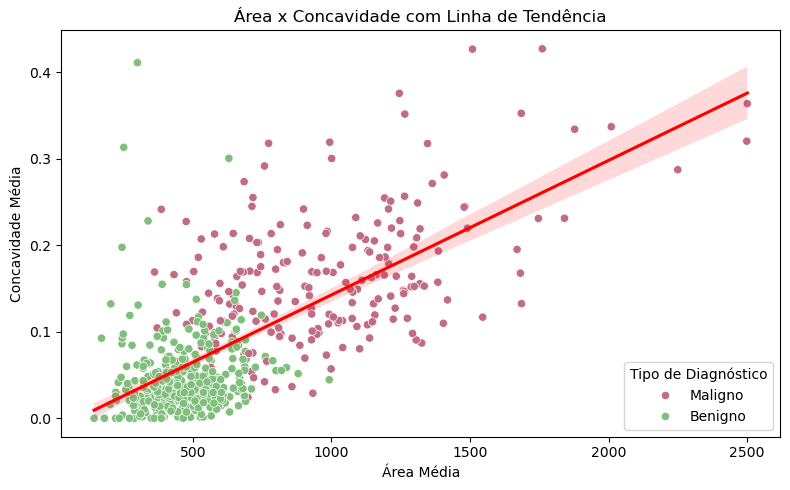

In [23]:
grafico_dispersao_linha(
    df=df,
    x="área média",
    y="concavidade média",
    hue="Tipo de Diagnóstico",
    titulo="Área x Concavidade com Linha de Tendência",
    eixo_x="Área Média",
    eixo_y="Concavidade Média",
    paleta=paleta_diagnostico,
    cor_linha="red"
)

2.6 Mapa de Correlação

In [24]:
def grafico_correlacao(df, titulo, cmap):
    plt.figure(figsize=(12, 8))
    
    sns.heatmap(
        df.corr(numeric_only=True),
        cmap=cmap,
        annot=False
    )
    
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

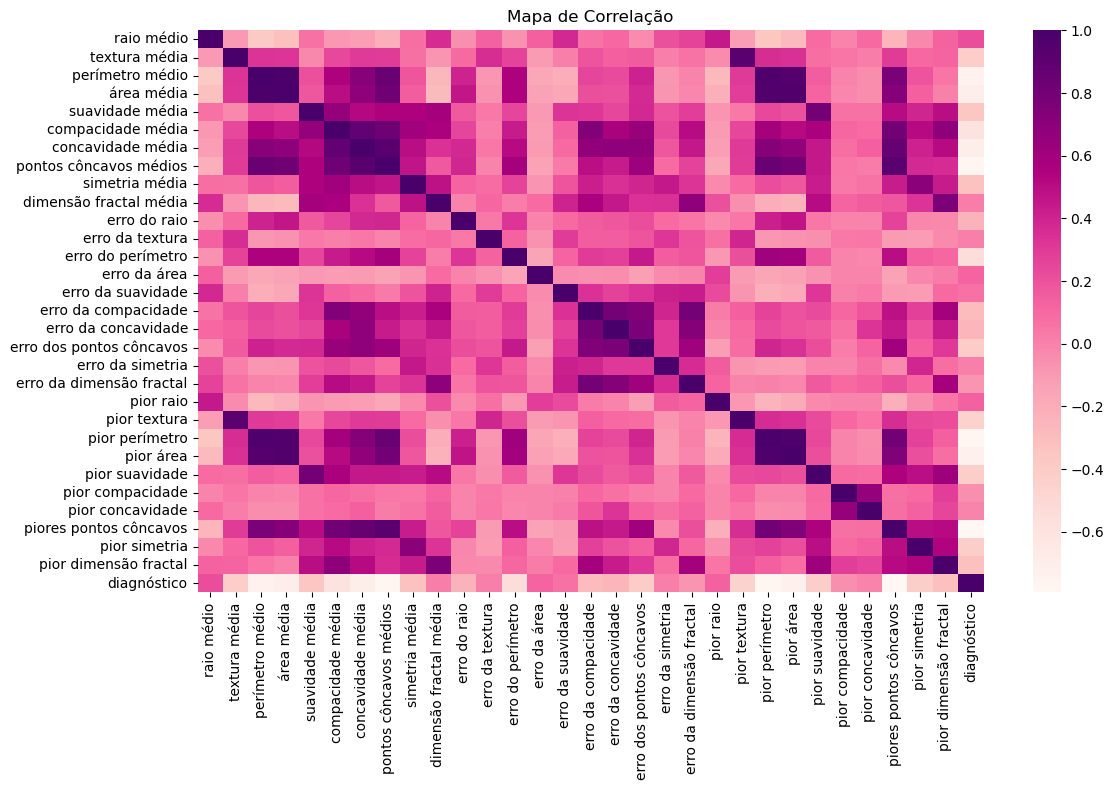

In [25]:
grafico_correlacao(
    df=df,
    titulo="Mapa de Correlação",
    cmap="RdPu"
)